In [ ]:
!pip install wordcloud nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem.snowball import SnowballStemmer

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [ ]:
# Đọc dữ liệu
df = pd.read_csv("D:\cuoiky\spam_Emails_data.csv")
df['spam'] = df['label'].map({'Spam': 1, 'Ham': 0}).astype(int)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\PC\AppData\Local\Temp\ipykernel_14896\1347436306.py:2: SyntaxWarning: invalid escape sequence '\c'
  df = pd.read_csv("D:\cuoiky\spam_Emails_data.csv")


In [ ]:
# Thông tin cơ bản
print("Kích thước: ", df.shape)
print(df.info())

Kích thước:  (193852, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193852 entries, 0 to 193851
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   193852 non-null  object
 1   text    193850 non-null  object
 2   spam    193852 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.4+ MB
None


In [ ]:
# Biểu đồ phân bố nhãn
sns.countplot(data=df, x='spam', hue='label', palette='Set2', legend=False)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Phân bố nhãn Ham và Spam')
plt.show()

In [ ]:
# Xử lý thiếu và trùng lặp
df.dropna(inplace=True)
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")

Số dòng trùng lặp: 0


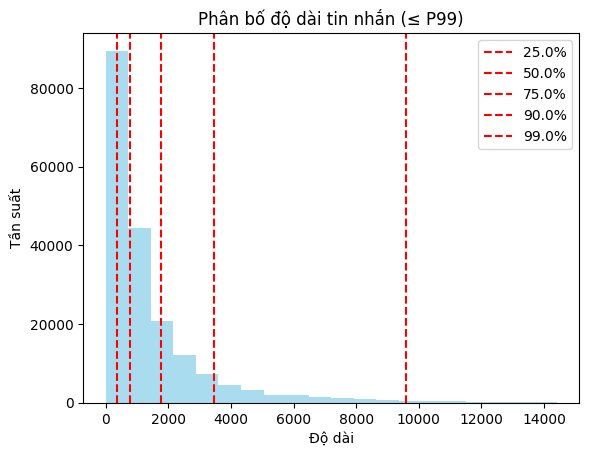

In [ ]:
# Độ dài tin nhắn
df['text_len'] = df['text'].apply(len)
no_outliers_df = df[df['text_len'] <= df['text_len'].quantile(0.99)]
percentiles = [0.25, 0.5, 0.75, 0.9, 0.99]
percentiles_value = np.quantile(no_outliers_df['text_len'], percentiles)

plt.hist(no_outliers_df['text_len'], bins=20, color='skyblue', alpha=0.7)
for percentile, value in zip(percentiles, percentiles_value):
    plt.axvline(value, color='r', linestyle='--', label=f'{percentile*100}%')
plt.title('Phân bố độ dài tin nhắn (≤ P99)')
plt.xlabel('Độ dài')
plt.ylabel('Tần suất')
plt.legend()
plt.show()

In [ ]:
# Làm sạch văn bản
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\S+", "", text)
    text = re.sub(r"#\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['text_cleaned'] = df['text'].apply(clean_text)

In [ ]:
# Tách từ
def tokenizer(text):
    return text.split() if isinstance(text, str) else []
df['text_cleaned'] = df['text_cleaned'].apply(tokenizer)

In [ ]:
porter = SnowballStemmer("english", ignore_stopwords=False)
def stem_it(text):
    return [porter.stem(word) for word in text]
df['text_cleaned'] = df['text_cleaned'].apply(stem_it)

In [ ]:
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def stop_it(text):
    return [word for word in text if word not in stop_words]
df['text_cleaned'] = df['text_cleaned'].apply(stop_it)

In [ ]:
# Ghép lại văn bản
df['text_cleaned'] = df['text_cleaned'].apply(' '.join)

# Xóa token không mong muốn
df['text_cleaned'] = df['text_cleaned'].str.replace(r'\bescapenumb\b', '', regex=True)
df['text_cleaned'] = df['text_cleaned'].str.replace(r'\bescapelong\b', '', regex=True)
df['text_cleaned'] = df['text_cleaned'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:

# Lưu file đã làm sạch (nếu muốn)
df.to_csv('D:\cuoiky\cleaned_spam_data.csv', index=False)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\PC\AppData\Local\Temp\ipykernel_14896\3749732169.py:2: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv('D:\cuoiky\cleaned_spam_data.csv', index=False)


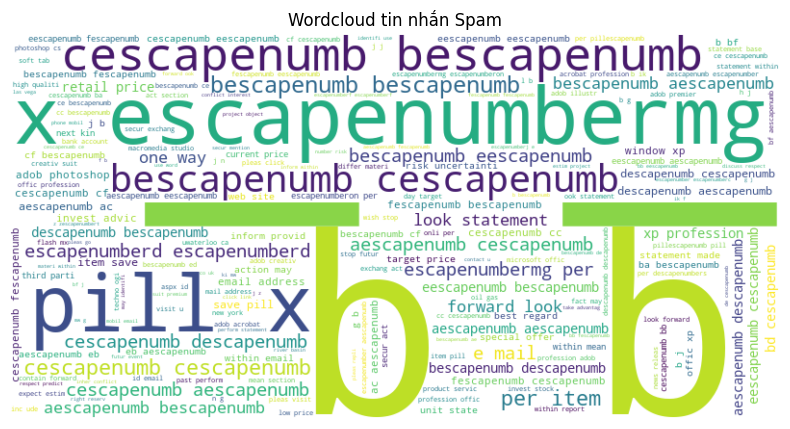

In [ ]:
# Wordcloud spam
spam_words = ' '.join(df[df['spam'] == 1]['text_cleaned'])
spam_wc = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
plt.figure(figsize=(10, 5))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud tin nhắn Spam')
plt.show()


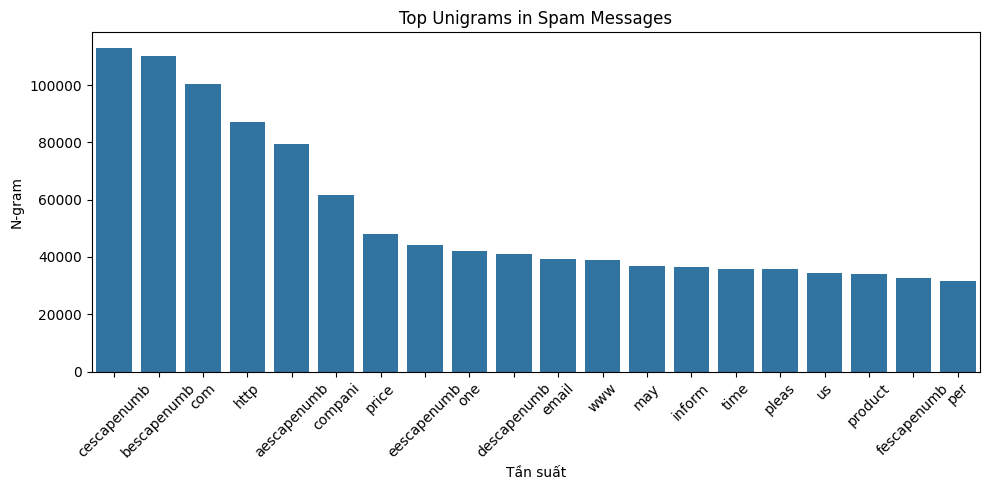

In [ ]:
# Hàm thống kê top n-grams
def plot_top_ngrams(corpus, ngram_range=(1,1), n=20, title='Top N-grams'):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]
    df_ngrams = pd.DataFrame(words_freq, columns=['ngram', 'count'])
    plt.figure(figsize=(10, 5))
    sns.barplot(x='ngram', y='count', data=df_ngrams)
    plt.title(title)
    plt.xlabel('Tần suất')
    plt.ylabel('N-gram')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_top_ngrams(df[df['spam'] == 1]['text_cleaned'], ngram_range=(1,1), title='Top Unigrams in Spam Messages')


In [ ]:
# Tạo TF-IDF vectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['text_cleaned'])
y = df['spam'].values

# Tách train/test
x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2, shuffle=False)

In [ ]:
# Huấn luyện mô hình
model = MultinomialNB()
model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
# Dự đoán
y_pred = model.predict(x_test)
print("Độ chính xác:", accuracy_score(y_test, y_pred))
print("Báo cáo phân loại:\n", classification_report(y_test, y_pred))

Độ chính xác: 0.9628320866649471
Báo cáo phân loại:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97     20568
           1       0.98      0.94      0.96     18202

    accuracy                           0.96     38770
   macro avg       0.96      0.96      0.96     38770
weighted avg       0.96      0.96      0.96     38770



In [ ]:
# ✅ Lưu TF-IDF và model
joblib.dump(tfidf, '\cuoiky\stfidf_vectorizer.pkl')
joblib.dump(model, '\cuoiky\model_naivebayes.pkl')

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\PC\AppData\Local\Temp\ipykernel_14896\1052907920.py:2: SyntaxWarning: invalid escape sequence '\c'
  joblib.dump(tfidf, '\cuoiky\stfidf_vectorizer.pkl')
C:\Users\PC\AppData\Local\Temp\ipykernel_14896\1052907920.py:3: SyntaxWarning: invalid escape sequence '\c'
  joblib.dump(model, '\cuoiky\model_naivebayes.pkl')


['\\cuoiky\\model_naivebayes.pkl']

<Figure size 600x500 with 0 Axes>

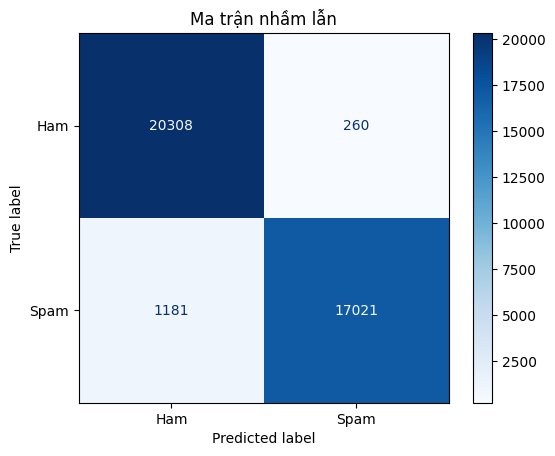

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])

plt.figure(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Ma trận nhầm lẫn')
plt.show()

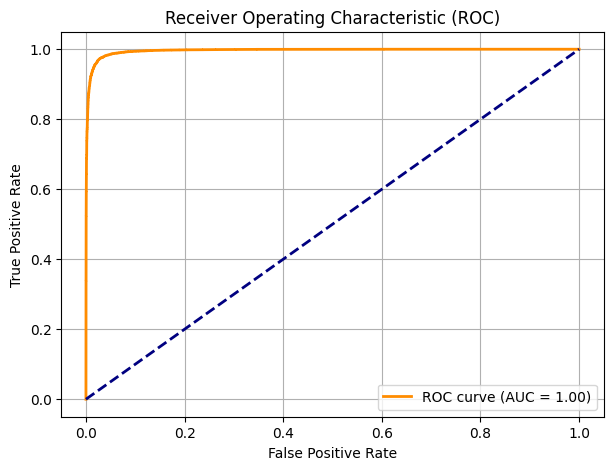

In [ ]:
from sklearn.metrics import roc_curve, auc

# Dự đoán xác suất
y_scores = model.predict_proba(x_test)[:, 1]

# Tính ROC và AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()
plt.show()


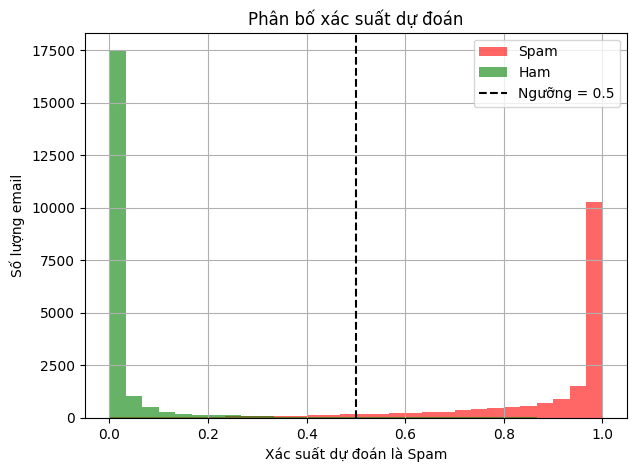

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(y_scores[y_test == 1], bins=30, alpha=0.6, label='Spam', color='red')
plt.hist(y_scores[y_test == 0], bins=30, alpha=0.6, label='Ham', color='green')
plt.axvline(0.5, color='black', linestyle='--', label='Ngưỡng = 0.5')
plt.title('Phân bố xác suất dự đoán')
plt.xlabel('Xác suất dự đoán là Spam')
plt.ylabel('Số lượng email')
plt.legend()
plt.grid(True)
plt.show()

## Deploy


In [8]:
from google.colab import drive
import joblib

In [9]:
# Tải mô hình đã huấn luyện
tfidf = joblib.load('/content/drive/MyDrive/NLP/mail_classifer/stfidf_vectorizer.pkl')
model = joblib.load('/content/drive/MyDrive/NLP/mail_classifer/model_naivebayes.pkl')

In [10]:
# làm sạch lại
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\S+", "", text)
    text = re.sub(r"#\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [11]:
# Hàm dự đoán
def predict_email(text):
    cleaned_text = clean_text(text)
    vector = tfidf.transform([cleaned_text])
    prediction = model.predict(vector)[0]
    return "Spam" if prediction == 1 else "Ham"

In [14]:
# Test thử
email = "Hi John, just a reminder about our meeting tomorrow at 10 AM. Let me know if you need anything before then."
print("Kết quả:", predict_email(email))

Kết quả: Ham


In [15]:
import gradio as gr

In [16]:
# Giao diện Gradio
interface = gr.Interface(
    fn=predict_email,
    inputs=gr.Textbox(lines=8, placeholder="Dán nội dung email tại đây..."),
    outputs=gr.Textbox(label="Kết quả"),
    title="📧 Bộ lọc Spam Email",
    description="Dán nội dung email vào ô bên dưới để kiểm tra xem đó là Spam hay Ham."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://21146d5a8e8e61de0a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
